# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Stock Prices Anomaly Detection

## Learning Objectives

At the end of the experiment, you will be able to :

* apply PCA based analysis on various stocks data
* analyze and create time series data
* implement LSTM auto-encoders
* detect the anomalies based on the loss


## Information

Autoencoder Neural Networks try to learn data representation of its input. Usually, we want to learn an efficient encoding that uses fewer parameters/memory. The encoding should allow for output similar to the original input. In a sense, we’re forcing the model to learn the most important features of the data using as few parameters as possible.

LSTM autoencoder is an encoder that makes use of LSTM encoder-decoder architecture to compress data using an encoder and decode it to retain original structure using a decoder.

**Anomaly Detection**

Anomaly detection refers to the task of finding/identifying rare events/data points. Some applications include - bank fraud detection, tumor detection in medical imaging, and errors in written text.

A lot of supervised and unsupervised approaches for anomaly detection have been proposed. Some of the approaches include - One-class SVMs, Bayesian Networks, Cluster analysis, and Neural Networks.

We will use an LSTM Autoencoder Neural Network to detect/predict anomalies (sudden price changes) in the S&P 500 index.

## Dataset



This mini-project consists of two parts and two different stock price datasets:

### PART A

Using the **S&P 500 stock prices data of different companies**, we will perform a PCA based analysis. 

### PART B

Using the **S&P 500 stock price index time series data**, we will perform anomaly detection in the stock prices across the years. The dataset chosen is is S&P500 Daily Index a .csv format with one column with a daily timestamp and the second column with the raw, un-adjusted closing prices for each day. This long term, granular time series dataset allows researchers to have a good sized publicly available financial dataset to explore time series trends or use as part of a quantitative finance project.

## Problem Statement

Detect the stock price anomalies by implementing an LSTM autoencoder

## Grading = 20 Points

In [67]:
#@title Download dataset
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/SPY.csv
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/prices.csv

### Import required packages

In [68]:
import keras
from keras.layers import Activation, Dense, Dropout, Flatten
from keras.layers import LSTM, RepeatVector, TimeDistributed
from keras.layers import BatchNormalization
from keras.models import Sequential, Model
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## PCA Analysis (PART-A)

Principal Component Analysis (PCA) decomposes the data into many vectors called principal components. These summaries are linear combinations of the input features that try to explain as much variance in the data as possible. By convention, these principal components are ordered by the amount of variance they can explain, with the first principal component explaining most of the data.

Perform PCA based analytics on the stock prices data from different companies.

Hint: Refer to the article [here](https://towardsdatascience.com/stock-market-analytics-with-pca-d1c2318e3f0e).

### Load and pre-process the prices data (2 points)

In [69]:
prices_path = "prices.csv"
prices_data = pd.read_csv(prices_path)
prices_data.head()
#len(prices_data)

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,85.017082,28.982893,157.171890,74.207466,81.950539,82.938141,168.809998,84.622925,204.910950,334.429993,...,59.934875,100.115349,63.633118,56.203197,78.396255,99.349007,147.579269,259.140015,49.903751,132.803421
2,83.652077,27.548195,157.181747,73.486023,81.172668,81.895088,166.820007,83.591301,204.569687,331.809998,...,60.223114,97.810677,63.121540,55.581242,78.857689,99.037834,147.193512,256.049988,49.199547,132.823227
3,83.899353,27.219410,154.598541,74.071579,81.813271,83.094116,179.039993,84.029251,203.233841,333.709991,...,60.136642,95.771927,63.606186,55.887280,78.347168,98.979500,146.342834,258.010010,48.600010,131.803482
4,84.156532,27.119778,152.764648,73.723213,81.346550,82.499466,180.350006,83.562103,198.846008,333.390015,...,60.011738,97.958405,63.085632,56.183449,78.052628,99.154533,146.214264,256.470001,48.305000,132.248978


In [70]:
prices_data.drop(prices_data.index[0],inplace = True)
df = prices_data.T
df

,1,2,3,4,5,6,7,8,9,10,...,384,385,386,387,388,389,390,391,392,393
A,85.017082,83.652077,83.899353,84.156532,84.987411,86.322769,86.639282,86.510704,87.034950,87.658119,...,149.509995,149.270004,148.630005,148.960007,148.929993,147.580002,149.300003,148.949997,150.300003,152.309998
AAL,28.982893,27.548195,27.219410,27.119778,27.737495,27.847092,27.219410,27.289152,27.428638,27.478453,...,20.840000,20.020000,20.620001,20.459999,19.790001,18.969999,20.559999,21.400000,21.160000,21.200001
AAP,157.171890,157.181747,154.598541,152.764648,151.009644,150.723709,146.917908,143.220551,146.809433,148.101074,...,211.929993,208.970001,210.160004,209.250000,205.850006,205.669998,210.229996,209.399994,210.289993,214.949997
AAPL,74.207466,73.486023,74.071579,73.723213,74.909149,76.500275,76.673225,78.311295,77.253838,76.922775,...,144.500000,145.639999,149.149994,148.479996,146.389999,142.449997,146.149994,145.399994,146.800003,148.559998
ABBV,81.950539,81.172668,81.813271,81.346550,81.923080,82.554535,81.502121,81.007950,81.805603,82.788773,...,116.333084,116.610001,117.360001,117.180000,117.500000,115.419998,116.050003,116.989998,117.540001,118.190002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YUM,99.349007,99.037834,98.979500,99.154533,99.329567,100.117195,98.882263,97.569534,97.939049,98.444672,...,117.870003,117.089996,117.120003,116.989998,115.849998,113.449997,116.160004,116.769997,120.260002,122.790001
ZBH,147.579269,147.193512,146.342834,146.214264,147.965027,146.985809,148.360703,147.401230,146.728638,146.540680,...,159.759995,157.039993,155.580002,153.100006,153.399994,150.169998,155.630005,159.570007,158.660004,159.970001
ZBRA,259.140015,256.049988,258.010010,256.470001,247.639999,246.500000,246.270004,248.580002,248.070007,247.800003,...,548.099976,533.619995,530.140015,522.619995,518.330017,506.910004,519.669983,533.770020,536.219971,548.609985
ZION,49.903751,49.199547,48.600010,48.305000,48.780827,49.104378,48.219357,48.552429,48.933083,47.933868,...,52.590000,51.410000,51.360001,51.669998,49.599998,47.700001,50.200001,51.639999,50.320000,50.860001


In [71]:
prices_data.fillna(method = 'bfill',inplace = True)

In [72]:
len(prices_data)

393

In [73]:
prices_data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [74]:
prices_data.dropna(inplace=True)

In [75]:
len(prices_data)

393

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(prices_data)

In [77]:
#prices_data.dropna(inplace=True)


### Apply PCA (6 points)

* plot the explained variance ratio. Hint: `pca.explained_variance_ratio_`
* Represent the components which preserve maximum information and plot to visualize
* Compute the daily returns of the 500 company stocks. Hint: See the following [reference](https://towardsdatascience.com/stock-market-analytics-with-pca-d1c2318e3f0e).
* Plot the stocks with most negative and least negative PCA weights in the pandemic period (Year 2020). Use reference as above. Discuss the least and most impacted industrial sectors in terms of stocks.

In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
prices_data_pca = pca.fit_transform(X_std)

principalDf = pd.DataFrame(data = prices_data_pca, columns = ['pc1', 'pc2','pc3'])

In [79]:
pca.components_

array([[-0.05091921, -0.03466414, -0.05084505, ..., -0.05100079,
        -0.04959886, -0.04608498],
       [-0.03376822,  0.08516257, -0.01764292, ..., -0.02003636,
         0.034678  , -0.04260331],
       [ 0.01206861,  0.00843899, -0.03359113, ...,  0.04052979,
         0.04342437, -0.05351613]])

In [80]:
pca.explained_variance_ratio_

array([0.6832315 , 0.13949245, 0.0444116 ])

In [81]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
d

1

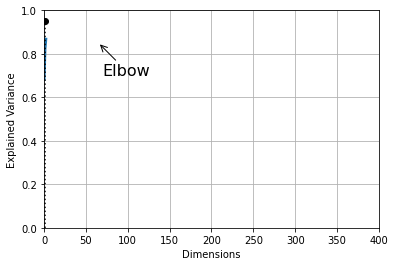

In [82]:
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"), fontsize=16)
plt.grid(True)
plt.show()

In [83]:
principalDf.head()

,pc1,pc2,pc3
0,3.718418,21.571040,1.934297
1,4.249783,21.824222,1.597905
2,4.155543,21.771343,1.276046
3,4.411957,21.785112,1.599032
4,4.025789,21.576053,1.375369


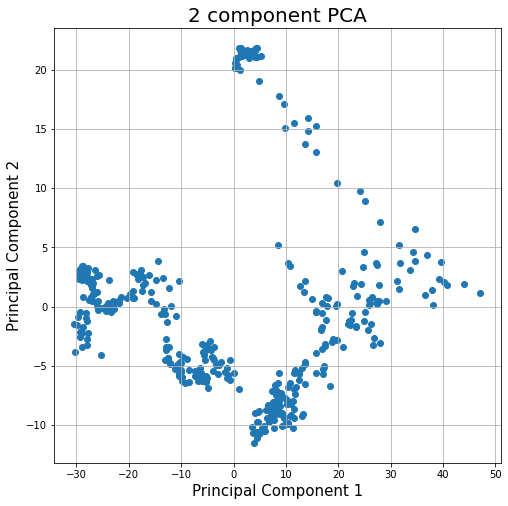

In [84]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)

ax.scatter(principalDf.pc1, principalDf.pc2)

ax.grid()

In [85]:
# Daily Returns
daily_returns = prices_data.apply(np.log).diff(1) 
daily_returns.tail()

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XEL,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
389,-0.009106,-0.042318,-0.000875,-0.027283,-0.017861,-0.002484,-0.010623,0.010834,-0.008791,-0.006704,...,-0.012518,0.005427,-0.034973,-0.007714,-0.018006,-0.020934,-0.021281,-0.022279,-0.039059,-0.009308
390,0.011587,0.080489,0.021929,0.025642,0.005444,0.033964,0.028112,-0.000505,0.009272,0.011018,...,-0.001612,0.013593,0.010961,0.030667,0.036023,0.023606,0.035713,0.024860,0.051084,0.012724
391,-0.002347,0.040043,-0.003956,-0.005145,0.008067,0.014742,-0.002289,0.002103,0.005465,0.005799,...,-0.016270,0.031756,0.031659,0.018680,0.007378,0.005238,0.025001,0.026771,0.028282,-0.010398
392,0.009023,-0.011278,0.004241,0.009583,0.004690,0.013610,0.002135,-0.006154,0.001561,0.018480,...,0.002681,0.008389,-0.011317,-0.007241,-0.003518,0.029450,-0.005719,0.004579,-0.025894,0.012545
393,0.013285,0.001889,0.021918,0.011918,0.005515,0.012192,0.015275,0.021335,0.013873,0.003505,...,0.015202,0.010134,-0.001226,0.004571,0.010275,0.020820,0.008223,0.022843,0.010674,0.015094


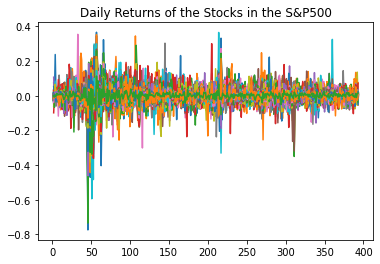

In [86]:
daily_returns.plot(title='Daily Returns of the Stocks in the S&P500',legend=None)

In [87]:
pca_returns = PCA(1).fit(daily_returns.fillna(0))
pc1 = pd.Series(index=daily_returns.columns, data=pca_returns.components_[0])
pc1.tail()

YUM    -0.034430
ZBH    -0.040196
ZBRA   -0.039866
ZION   -0.051452
ZTS    -0.029029
dtype: float64

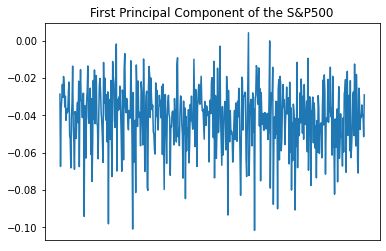

In [88]:
pc1.plot(xticks=[], title='First Principal Component of the S&P500')

In [89]:
cumulative_returns = daily_returns.cumsum().apply(np.exp)

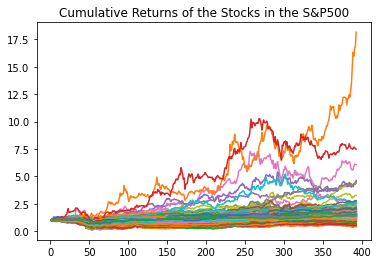

In [90]:
cumulative_returns.plot(title='Cumulative Returns of the Stocks in the S&P500',legend=None)

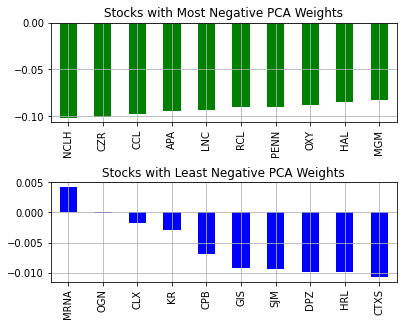

In [91]:
fig, ax = plt.subplots(2,1)
fig.tight_layout()

pc1.nsmallest(10).plot.bar(ax=ax[0], color='green', grid=True, title='Stocks with Most Negative PCA Weights')
pc1.nlargest(10).plot.bar(ax=ax[1], color='blue', grid=True, title='Stocks with Least Negative PCA Weights')
plt.subplots_adjust(left=0.1,
                    bottom=0, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.5, 
                    hspace=0.6)
plt.show()

**Most impacted** : N.Cruise Line Holdings, Caesars Entertainment, Carnival Corp, Hydrocarbon exploration, Insurance and Investment management, royal carribean corp, casinos, racetracks, liquified natural gas, oil field service, hydraulic fracturing operations, resorts

**Least Impacted/Profited**: Moderna (Vaccines), Pharmaceuticals, Clorox cleaning products, disinfectants, department stores, soup, food products,pizza, Citrix systems

#### Apply T-SNE and visualize with a graph (2 points)

In [92]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
prices_data_tsne = tsne.fit_transform(X_std)
prices_data_tsne.shape

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


(393, 2)

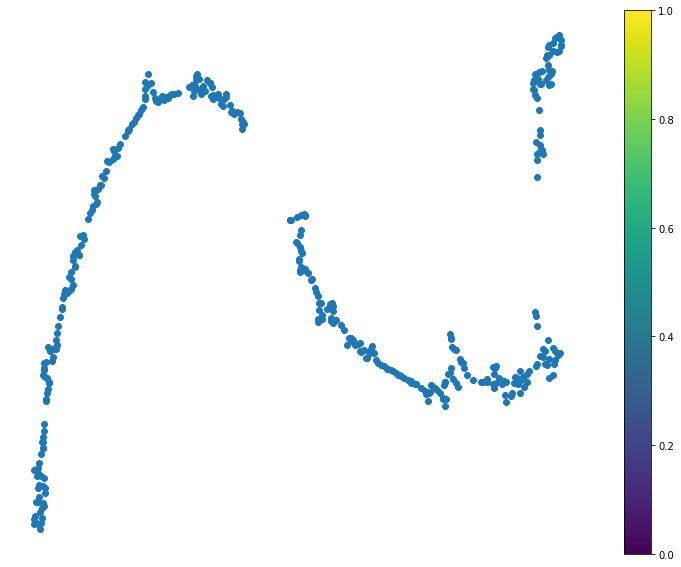

In [93]:
plt.figure(figsize=(13,10))
plt.scatter(prices_data_tsne[:, 0], prices_data_tsne[:, 1], cmap="jet")
plt.axis('off')
plt.colorbar()
plt.show()

## Anomaly Detection (PART-B)

### Load and Preprocess the data

* Inspect the S&P 500 Index Data

In [94]:
path = 'SPY.csv'

In [95]:
sp_data = pd.read_csv(path)
sp_data.head()
len(sp_data)

7134

#### Data Preprocessing (1 point)

In [96]:
sp_data.isna().sum().sum()
sp_data.shape
sp_data.head()
sp_data.isnull().sum().sum()

0

In [97]:
sp_data = sp_data.set_index('Date')
sp_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1993-02-01,43.96875,44.25000,43.96875,44.25000,25.983273,480500
1993-02-02,44.21875,44.37500,44.12500,44.34375,26.038315,201300
1993-02-03,44.40625,44.84375,44.37500,44.81250,26.313566,529400
1993-02-04,44.96875,45.09375,44.46875,45.00000,26.423655,531500
1993-02-05,44.96875,45.06250,44.71875,44.96875,26.405315,492100


In [98]:
sp_data.drop(columns=['Open','High','Low','Volume','Adj Close'],inplace=True)


In [99]:
sp_data.tail()

,Close
Date,
2021-05-24,419.170013
2021-05-25,418.239990
2021-05-26,419.070007
2021-05-27,419.290009
2021-05-28,420.040009


Share price visualization:


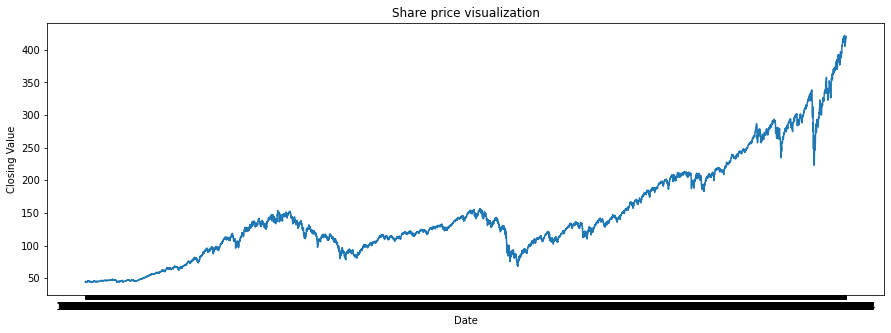

In [100]:
print('Share price visualization:')
plt.figure(figsize = (15,5))
plt.plot(sp_data)
plt.title('Share price visualization')
plt.xlabel ('Date')
plt.ylabel ('Closing Value')
plt.show()

Box plot visualization:


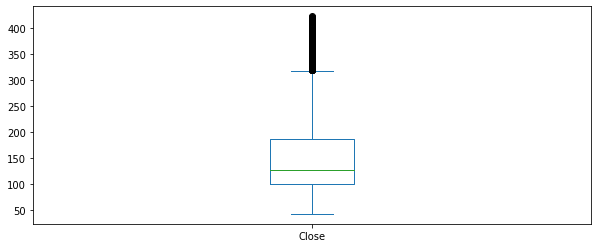

In [101]:
# Generate Boxplot
print('Box plot visualization:')
sp_data.plot(kind='box', figsize = (10,4))
plt.show()

Histogram visualization:


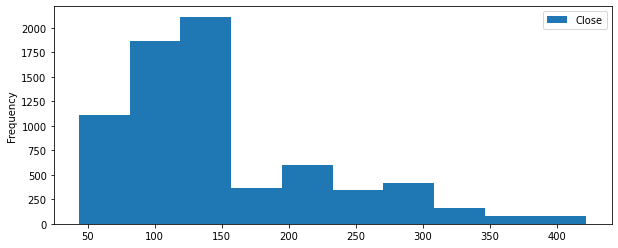

In [102]:
# Generate Histogram
print('Histogram visualization:')
sp_data.plot(kind='hist', figsize = (10,4) )
plt.show()

### Create time series data ( 1 point)

Select the variable (column) from the data and create the series of data with a window size.

Refer [LSTM Autoencoder](https://medium.com/swlh/time-series-anomaly-detection-with-lstm-autoencoders-7bac1305e713)

In [103]:
train_size = int(len(sp_data)*0.95)
test_size = len(sp_data) - train_size
train_size
test_size

357

In [104]:
train,test = sp_data.iloc[0:train_size],sp_data.iloc[train_size:len(sp_data)]
print(train.shape)
print(test.shape)

(6777, 1)
(357, 1)


In [105]:
# data standardization
from sklearn.preprocessing import RobustScaler
robust = RobustScaler(quantile_range=(25, 75)).fit(train[['Close']])
train['price'] = robust.transform(train[['Close']])
test['price'] = robust.transform(test[['Close']])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [106]:
# Using window size as 30 (1 month)
def create_dataset(X, y, time_steps=1):
  a, b = [], []
  for i in range(len(X) - time_steps):
     v = X.iloc[i:(i + time_steps)].values
     #print("\n i= ",i)
     #print("\n v= ", v)
     a.append(v)
     #print("\n Append to b: ",y.iloc[i + time_steps])
     b.append(y.iloc[i + time_steps])
  return np.array(a), np.array(b)

# We’ll create sequences with 30 days of historical data
n_steps = 30

# reshape to 3D [n_samples, n_steps, n_features]
X_train, y_train = create_dataset(train[['price']], train['price'], n_steps)
X_test, y_test = create_dataset(test[['price']], test['price'], n_steps)

print('X_train shape: ', X_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)


X_train shape:  (6747, 30, 1)
y_train shape:  (6747,)
X_test shape: (327, 30, 1)
y_test shape: (327,)


### Build an LSTM Autoencoder ( 2 points)

Autoencoder should take a sequence as input and outputs a sequence of the same shape.

Hint: [LSTM Autoencoder](https://medium.com/swlh/time-series-anomaly-detection-with-lstm-autoencoders-7bac1305e713)

In [107]:
units = 64
dropout = 0.10
optimizer = 'adam'
loss = 'mae'
epochs = 30

### Train the Autoencoder (1 point)

* Compile and fit the model with required parameters

In [108]:
model = keras.Sequential()
model.add(keras.layers.LSTM(units=units,input_shape=(X_train.shape[1],X_train.shape[2])))
model.add(keras.layers.Dropout(rate=dropout))
model.add(keras.layers.RepeatVector(n=X_train.shape[1]))
model.add(keras.layers.LSTM(units=units,return_sequences=True))
model.add(keras.layers.Dropout(rate=dropout))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))
model.compile(optimizer=optimizer, loss=loss)
history = model.fit(X_train,y_train,epochs=epochs, batch_size=32,validation_split=0.1,shuffle=False)

Epoch 1/30
190/190 [==============================] - 12s 43ms/step - loss: 0.1508 - val_loss: 0.3576
Epoch 2/30
190/190 [==============================] - 7s 38ms/step - loss: 0.0827 - val_loss: 0.4380
Epoch 3/30
190/190 [==============================] - 7s 37ms/step - loss: 0.0891 - val_loss: 0.2042
Epoch 4/30
190/190 [==============================] - 8s 40ms/step - loss: 0.0862 - val_loss: 0.1505
Epoch 5/30
190/190 [==============================] - 7s 38ms/step - loss: 0.0908 - val_loss: 0.2145
Epoch 6/30
190/190 [==============================] - 7s 38ms/step - loss: 0.0771 - val_loss: 0.2038
Epoch 7/30
190/190 [==============================] - 7s 37ms/step - loss: 0.0681 - val_loss: 0.1935
Epoch 8/30
190/190 [==============================] - 7s 37ms/step - loss: 0.0696 - val_loss: 0.2216
Epoch 9/30
190/190 [==============================] - 7s 38ms/step - loss: 0.0675 - val_loss: 0.1859
Epoch 10/30
190/190 [==============================] - 7s 38ms/step - loss: 0.0707 - val_l

#### Plot metrics and evaluate the model (2 point)

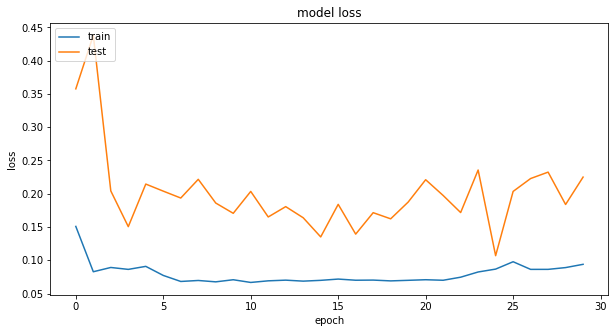

In [109]:
# history for loss
plt.figure(figsize = (10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [110]:
# Calculating MAE on train data
train_pred = model.predict(X_train)
train_loss = (np.mean(np.abs(train_pred-X_train),axis=1))
avg_loss = train_loss.mean()
train_loss
print("Training Loss: ", avg_loss)

Training Loss:  0.13514849811060184


In [111]:
train_pred.shape

(6747, 30, 1)

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


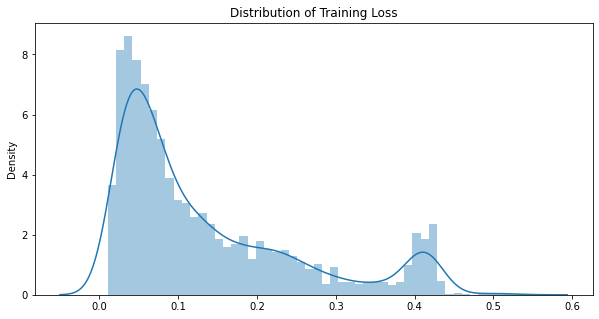

In [112]:
plt.figure(figsize=(10,5))
sns.distplot(train_loss,bins=50,kde=True)
plt.title("Distribution of Training Loss")
plt.show()

In [ ]:
# Accuracy metrics on test data
# MAE on the test data:
y_pred = model.predict(X_test)
print('Predict shape:', y_pred.shape)
mae = np.mean(np.abs(y_pred - X_test), axis=1)
print("Mean absolute error = ", mae)

In [114]:
# reshaping prediction
pred = y_pred.reshape((y_pred.shape[0] * y_pred.shape[1]), y_pred.shape[2])
print('Prediction:', pred.shape); print();
print('Test data shape:', X_test.shape); print();

# reshaping test data
X_test = X_test.reshape((X_test.shape[0] * X_test.shape[1]), X_test.shape[2])
print('Test data:', X_test.shape); print();

Prediction: (9810, 1)

Test data shape: (327, 30, 1)

Test data: (9810, 1)



In [115]:
import math
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
# error computation
errors = X_test - pred
print('Shape of errors:', errors.shape); print();

# rmse on test data
RMSE = math.sqrt(mean_squared_error(X_test, pred))
print('Test RMSE: %.3f' % RMSE);

Shape of errors: (9810, 1)

Test RMSE: 1.101


### Detect Anomalies in the S&P 500 Index Data (3 points)

* Predict the data and calculate the loss
* Define threshold and detect the anomalies

Discuss the Impact of COVID19 pandemic on stock prices in terms of anomalies detected during the pandemic period in stock prices

In [117]:
# Finding the threshold for cutoff
dist = np.linalg.norm(X_test-pred, axis=1)
scores = dist.copy()
print(scores.shape)

(9810,)


In [118]:
scores.sort()

In [120]:
cut_off = int(0.80*len(scores))
cut_off

7848

In [124]:
threshold = scores[cut_off]
print("threshold: ", threshold)

threshold:  1.493528496186865


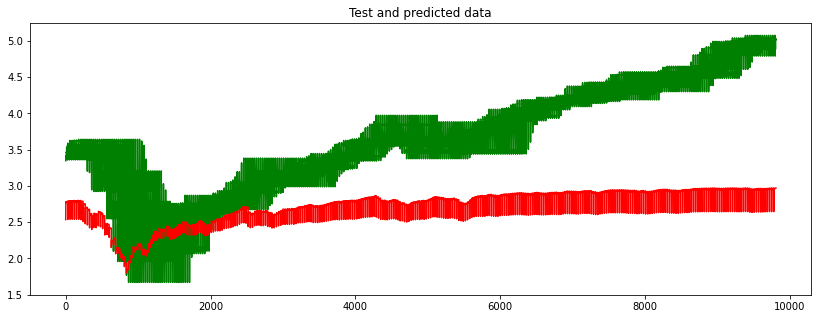

In [125]:
plt.figure(figsize=(14,5))

plt.plot(X_test, color='green')
plt.plot(pred,color='red')
plt.title("Test and predicted data")
plt.show()

In [127]:
score = pd.DataFrame(index=test[n_steps:].index)
score

""
Date
2020-02-12
2020-02-13
2020-02-14
2020-02-18
2020-02-19
...
2021-05-24
2021-05-25
2021-05-26


In [129]:
score['loss'] = mae
score['threshold'] = threshold
score['anomaly'] = score['loss'] > score['threshold']
score['price'] = test[n_steps:].price

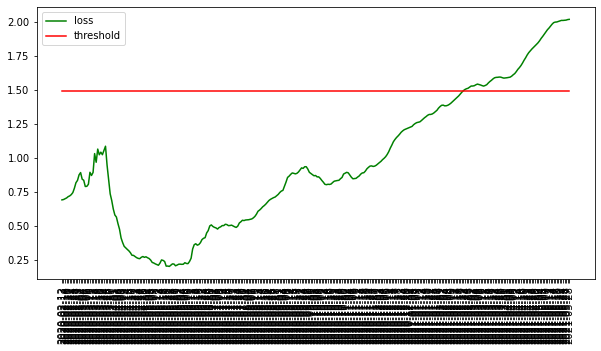

In [130]:
plt.figure(figsize=(10,5))
plt.plot(score.index,score['loss'],color='green',label='loss')
plt.plot(score.index,score['threshold'],color='red',label='threshold')
plt.xticks(rotation=90)
plt.legend()

In [131]:
anomalies = score[score['anomaly'] == True]
x = pd.DataFrame(anomalies.price)

In [132]:
x = pd.DataFrame(robust.inverse_transform(x))

In [133]:
x.index = anomalies.index

In [134]:
x.rename(columns={0:'inverse_price'},inplace=True)


In [135]:
anomalies = anomalies.join(x,how='left')
anomalies = anomalies.drop(columns=['price'],axis=1)
anomalies.tail(10)

,loss,threshold,anomaly,inverse_price
Date,,,,
2021-05-17,1.999733,1.493528,True,415.519989
2021-05-18,2.000653,1.493528,True,411.940002
2021-05-19,2.004815,1.493528,True,410.859985
2021-05-20,2.009755,1.493528,True,415.279999
2021-05-21,2.012304,1.493528,True,414.940002
2021-05-24,2.012051,1.493528,True,419.170013
2021-05-25,2.013413,1.493528,True,418.239990
2021-05-26,2.014455,1.493528,True,419.070007
2021-05-27,2.018301,1.493528,True,419.290009


In [136]:
test_inv = pd.DataFrame(robust.inverse_transform(test[n_steps:]))
test_inv.index = test[n_steps:].index

In [138]:
test_inv.rename(columns={0:'price'},inplace=True)

In [144]:
test_inv

,price,1
Date,,
2020-02-12,19843.914224,337.420013
2020-02-13,19822.875346,337.059998
2020-02-14,19854.432771,337.600006
2020-02-18,19803.591343,336.730011
2020-02-19,19897.676876,338.339996
...,...,...
2021-05-24,24621.282136,419.170013
2021-05-25,24566.932742,418.239990
2021-05-26,24615.437904,419.070007


In [145]:
test_inv.drop(columns=['price'],inplace=True)


In [149]:
test_inv.rename(columns={1:'price'},inplace=True)

In [150]:
test_inv

,price
Date,
2020-02-12,337.420013
2020-02-13,337.059998
2020-02-14,337.600006
2020-02-18,336.730011
2020-02-19,338.339996
...,...
2021-05-24,419.170013
2021-05-25,418.239990
2021-05-26,419.070007


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


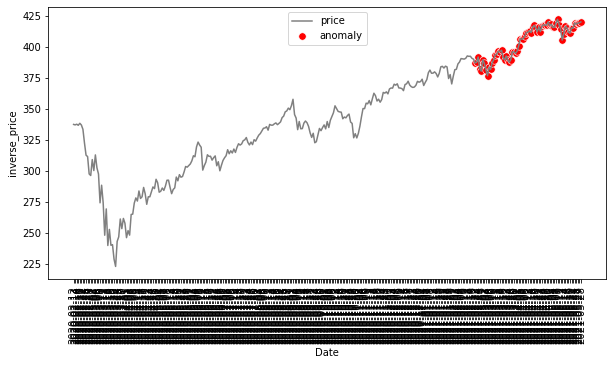

In [151]:
plt.figure(figsize=(10,5))
plt.plot(test_inv.index,test_inv.price,color='gray',label='price')
sns.scatterplot(anomalies.index,anomalies.inverse_price,color='red',s=55,label='anomaly')
plt.xticks(rotation=90)
plt.legend(loc="upper center")


### Report Analysis

* Discuss on the results of T-SNE and PCA
* Dicuss about the results of LSTM autoencoder